# Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
import os
import sys

project_root = os.path.abspath('..')
sys.path.append(project_root)

# Customer Table Analyis

## Conclusions:
The customer dataset has 99,441 rows with 5 attributes and no nulls. The dataset is fine grain with each row having a unique ``customer_id`` which according to the explanation given with the dataset is uniquely generated for each order. ``customer_unique_id`` is not distinct as it is unique for each customer and is thus repeated across orders. 41.98% of orders are from Sao Paolo state with 15% orders in Sao Paolo city.

*Note: Given this datasets grain is based on orders and not customer profiles, its name is currently misleading. To acutaully represent customer data (where the table actually represents the location profiles of unique customers) it would have to be modified to make the ``customer_unique_id`` the primary key and then remove the ``customer_id`` attribute. The utulity of this however depends on the presence of ```customer_unique_id``` in other datasets.*

In [3]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
customers.reset_index()
customers = customers.replace({None: np.nan})
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [5]:
customers.describe(include = "str")

,customer_id,customer_unique_id,customer_city,customer_state
count,99441,99441,99441,99441
unique,99441,96096,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,sao paulo,SP
freq,1,17,15540,41746


In [6]:
customers.duplicated().sum()

np.int64(0)

In [7]:
from src.utils import value_counts_per

value_counts_per(customers.drop_duplicates(subset = "customer_unique_id"), "customer_city")[:5]

,count,percentage
customer_city,,
sao paulo,14971,15.58
rio de janeiro,6611,6.88
belo horizonte,2671,2.78
brasilia,2066,2.15
curitiba,1462,1.52


In [8]:
value_counts_per(customers.drop_duplicates(subset = "customer_unique_id"), "customer_state")[:5]

,count,percentage
customer_state,,
SP,40295,41.93
RJ,12377,12.88
MG,11255,11.71
RS,5277,5.49
PR,4882,5.08


# Geolocation Table Analysis

## Conclusions: 

The geolocation dataset has over a million entries, 5 attributes, and no nulls. 

There are more unique cities in the geolocation dataset compared to the customers dataset.

There are multiple duplicated values and multiple co-ordinates per zipcode. So I have applied agreggation where the mean is calcuted for each unique ```geolocation_zip_code_prefix```.

In [9]:
geo = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
geo .reset_index()
geo  = geo .replace({None: np.nan})
geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [10]:
#No nulls, 5 attributes
geo.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


In [11]:
#geolocation_city unique > customer_city unique
#gelocation_state unique > customer_city unique
geo.describe(include = 'str')

,geolocation_city,geolocation_state
count,1000163,1000163
unique,8011,27
top,sao paulo,SP
freq,135800,404268


In [12]:
geo.nunique()

geolocation_zip_code_prefix     19015
geolocation_lat                717360
geolocation_lng                717613
geolocation_city                 8011
geolocation_state                  27
dtype: int64

In [13]:
#Multiple duplicated locations
geo.duplicated().sum()

np.int64(261831)

In [14]:
#Multiple duplicated co-ordinates?
geo[["geolocation_lat", "geolocation_lng"]].duplicated().sum()

np.int64(281700)

In [15]:
geo.groupby('geolocation_zip_code_prefix')[['geolocation_city', 'geolocation_state']] \
.nunique().sort_values(by='geolocation_city', ascending=False).head(10)

,geolocation_city,geolocation_state
geolocation_zip_code_prefix,,
17970,5,1
13455,5,1
78290,5,1
6900,5,1
13318,5,1
13457,5,1
13454,5,1
28950,5,1
42850,5,1


In [16]:
#There are up to 746 different latitude and longitutde co-ordinates under each zip code prefix.
geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']] \
.nunique().sort_values(by='geolocation_lat', ascending=False).head(10)

,geolocation_lat,geolocation_lng
geolocation_zip_code_prefix,,
38400,746,745
11680,726,726
35500,726,726
11740,666,666
36400,627,627
39400,618,620
35162,611,611
38408,600,599
37200,595,594


Text(0.5, 1.0, 'Top 10 Cities by Occurence')

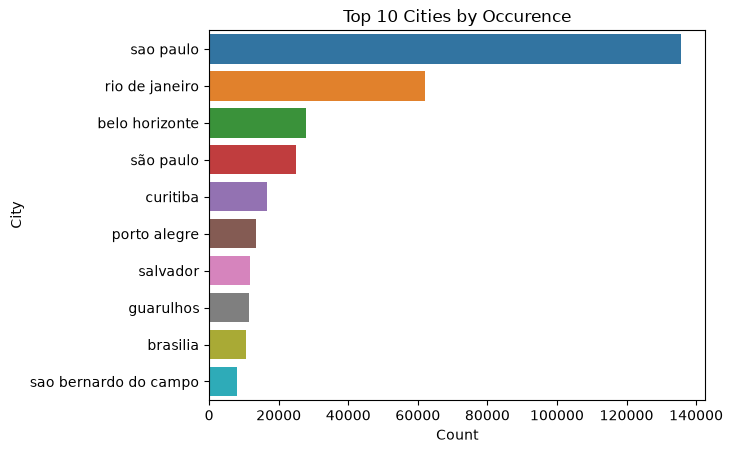

In [17]:
t = geo['geolocation_city'].value_counts().head(10)
fig = sns.barplot(x = t.values, y = t.index, hue = t.index)
plt.xlabel("Count")
plt.ylabel("City")
plt.title("Top 10 Cities by Occurence")

### Calculating a Geographic Centroid for each ```geolocation_zip_code_prefix```

In [18]:
geo[['geolocation_lat', 'geolocation_lng']] = geo.groupby("geolocation_zip_code_prefix")[['geolocation_lat', 'geolocation_lng']].transform('mean')

In [19]:
geo[geo['geolocation_zip_code_prefix'] == 1020]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
21,1020,-23.552336,-46.63005,são paulo,SP
47,1020,-23.552336,-46.63005,sao paulo,SP
50,1020,-23.552336,-46.63005,sao paulo,SP
88,1020,-23.552336,-46.63005,sao paulo,SP
138,1020,-23.552336,-46.63005,são paulo,SP
...,...,...,...,...,...
1344,1020,-23.552336,-46.63005,sao paulo,SP
1380,1020,-23.552336,-46.63005,sao paulo,SP
1394,1020,-23.552336,-46.63005,sao paulo,SP
1434,1020,-23.552336,-46.63005,sao paulo,SP


# Order Items Table

## Conclusions

In [20]:
ot = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
ot .reset_index()
ot  = ot.replace({None: np.nan})
ot.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [21]:
ot["shipping_limit_date"] = pd.to_datetime(ot["shipping_limit_date"])
ot.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


In [22]:
ot.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


In [23]:
ot.nunique()

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

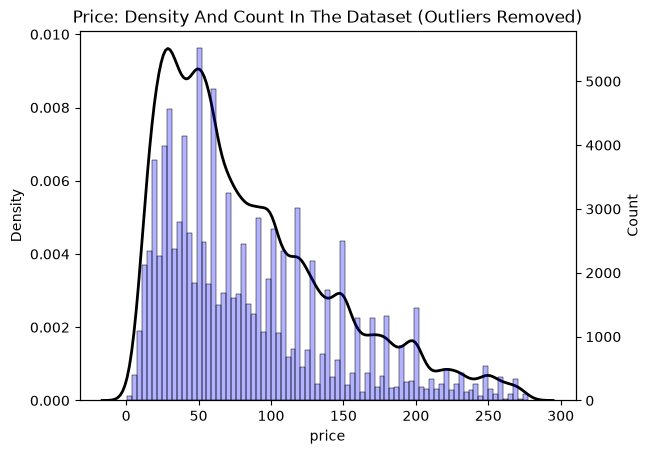

In [27]:
from src.utils import count_density_plot
count_density_plot(ot, x = "price")


In [25]:
data1 = ot[~find_outliers(ot, columns = ["price"])]

fig, ax1 = plt.subplots()

sns.kdeplot(data1, x = "price", linewidth = 2, ax = ax1, color = "Black", label = "Density")

ax1.set_ylabel("Density")

ax2 = ax1.twinx()

sns.histplot(data1, x = "price", ax = ax2, alpha=0.3, stat = "count", color = "Blue", label = "count")

ax2.set_ylabel("Count")
ax1.set_xlabel("Price")
ax1.set_title("Price: Density and Count in the Dataset (Outliers Removed)")

plt.show()

NameError: name 'find_outliers' is not defined

<Axes: xlabel='freight_value', ylabel='Density'>

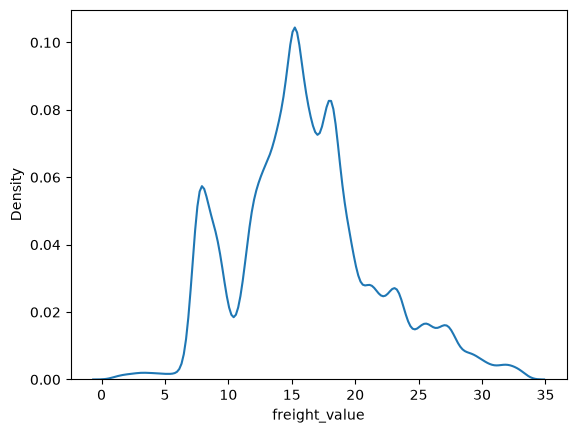

In [ ]:
sns.kdeplot(ot[~find_outliers(ot, columns = ["freight_value"])], x = "freight_value")

<Axes: xlabel='shipping_limit_date'>

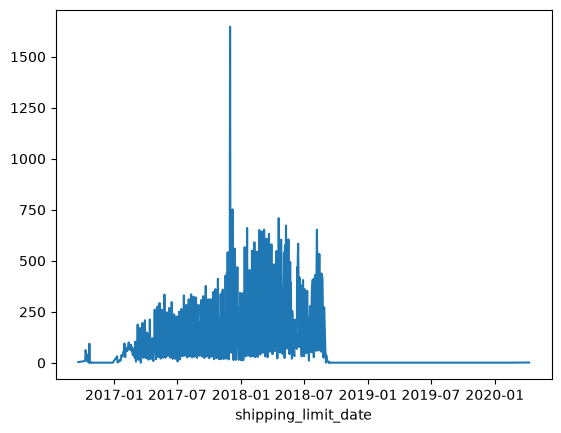

In [ ]:
count = ot.groupby(ot["shipping_limit_date"].dt.date).size()
sns.lineplot(x = count.index, y = count.values)